# Predicting Outcomes + Testing Models in Practice
**Assignment**

**Dataset.** Wisconsin Diagnostic Breast Cancer (WDBC), a public dataset (UCI repository, bundled with scikit-learn): 569 breast-mass samples, 30 numeric features computed from digitised images of fine-needle aspirates, and a diagnosis label.
**Task.** Binary classification: predict whether a mass is *malignant* (1) or *benign* (0).
**Why this dataset.** It is public, has features plus a target, runs in seconds, and is high-stakes enough that the testing questions in Part B (false negatives, fairness, input validation) are meaningful.
**Important.** This is a learning project, not a medical device.

**Contents**
1. Part A: data import and cleaning, EDA, feature engineering, model development, findings
2. Part B: validation plan, metrics, overfitting/underfitting tests, fairness (subgroup) tests, robustness tests, API test cases, Responsible AI notes

---
# Part A: Build a Data Project

## 1. Data import and cleaning

In [1]:
import os, time, numbers, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_score, GridSearchCV, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, brier_score_loss, confusion_matrix,
                             classification_report, roc_curve)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
PALETTE = {"benign": "#4C78A8", "malignant": "#E45756"}
os.makedirs("figs", exist_ok=True)

In [2]:
# The Wisconsin Diagnostic Breast Cancer (WDBC) dataset ships with scikit-learn.
# We export it to a CSV first so the notebook follows the "load a CSV" workflow.
bunch = load_breast_cancer(as_frame=True)
raw = bunch.frame.copy()
raw.columns = [c.replace(" ", "_") for c in raw.columns]
# scikit-learn codes malignant = 0. We flip it so that 1 = malignant, the class we most need to catch.
raw["malignant"] = (raw["target"] == 0).astype(int)
raw = raw.drop(columns="target")
raw.to_csv("wdbc.csv", index=False)

df = pd.read_csv("wdbc.csv")
print("Shape (rows, columns):", df.shape)
print()
print(df.iloc[:5, [0, 1, 2, 3, -1]].to_string())
print()
print("Column types:")
print(df.dtypes.value_counts().to_string())

Shape (rows, columns): (569, 31)

   mean_radius  mean_texture  mean_perimeter  mean_area  malignant
0        17.99         10.38          122.80     1001.0          1
1        20.57         17.77          132.90     1326.0          1
2        19.69         21.25          130.00     1203.0          1
3        11.42         20.38           77.58      386.1          1
4        20.29         14.34          135.10     1297.0          1

Column types:
float64    30
int64       1


**What this checks.** Missing values, duplicates, and zero values that could be hidden missing-data codes.

In [3]:
print("Total missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

features_only = df.drop(columns="malignant")
zeros = (features_only == 0).sum()
print("\nColumns containing exact zeros:")
print(zeros[zeros > 0].to_string())
print("\nSummary of the first 6 features:")
print(features_only.describe().T[["min", "mean", "max"]].head(6).round(3).to_string())

Total missing values: 0
Duplicate rows: 0

Columns containing exact zeros:
mean_concavity          13
mean_concave_points     13
concavity_error         13
concave_points_error    13
worst_concavity         13
worst_concave_points    13

Summary of the first 6 features:
                      min     mean       max
mean_radius         6.981   14.127    28.110
mean_texture        9.710   19.290    39.280
mean_perimeter     43.790   91.969   188.500
mean_area         143.500  654.889  2501.000
mean_smoothness     0.053    0.096     0.163
mean_compactness    0.019    0.104     0.345


**Findings.** The dataset has **no missing values and no duplicate rows**. Six concavity-related columns contain exactly 13 zeros each. Zero concavity is physically meaningful here (a perfectly smooth outline), so these are real measurements, not missing-data codes, and are left as they are.

Because real-world data usually does have gaps, the preprocessing pipeline built later still includes **median imputation**, and Part B tests it by injecting missing values.

Share of rows flagged as outliers (IQR rule), top 8 features:
area_error                 11.4
radius_error                6.7
perimeter_error             6.7
worst_area                  6.2
smoothness_error            5.3
fractal_dimension_error     4.9
compactness_error           4.9
symmetry_error              4.7

Rows with at least one outlier: 30.1%
Share of rows with an outlier, by class (1 = malignant):
malignant
0    0.160
1    0.538


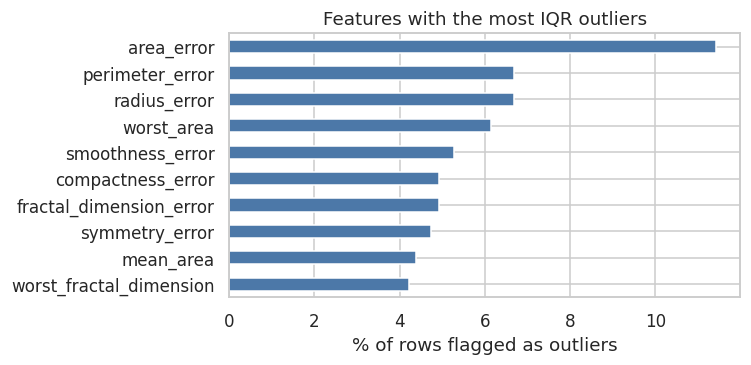

In [4]:
q1, q3 = features_only.quantile(0.25), features_only.quantile(0.75)
iqr = q3 - q1
outlier_mask = (features_only < q1 - 1.5 * iqr) | (features_only > q3 + 1.5 * iqr)
out_pct = outlier_mask.mean().mul(100).sort_values(ascending=False)

print("Share of rows flagged as outliers (IQR rule), top 8 features:")
print(out_pct.head(8).round(1).to_string())
rows_with_outlier = outlier_mask.any(axis=1)
print("\nRows with at least one outlier: %.1f%%" % (rows_with_outlier.mean() * 100))
print("Share of rows with an outlier, by class (1 = malignant):")
print(rows_with_outlier.groupby(df["malignant"]).mean().round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 3.5))
out_pct.head(10).sort_values().plot.barh(ax=ax, color="#4C78A8")
ax.set_xlabel("% of rows flagged as outliers")
ax.set_title("Features with the most IQR outliers")
plt.tight_layout()

**Findings.** 30.1% of rows have at least one value outside the 1.5 x IQR fences, but they are not spread evenly: **53.8% of malignant rows vs 16.0% of benign rows** contain an outlier. These look like genuine large-tumour measurements rather than data-entry errors, and they are concentrated in exactly the class we most need to detect.

**Decision.** Do **not** delete outlier rows (that would remove the hardest, most important cases). Instead, cap each feature at its 1st and 99th percentile, learned **on the training data only** inside the pipeline, to limit the pull of extreme values on the model.

## 2. Exploratory data analysis

diagnosis
benign       357
malignant    212
diagnosis
benign       62.7
malignant    37.3


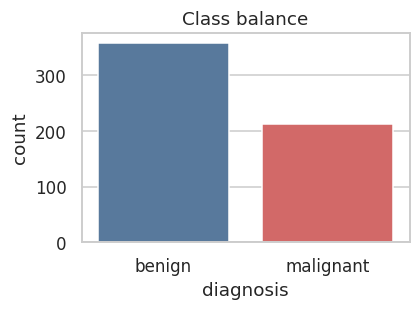

In [5]:
eda = df.assign(diagnosis=df["malignant"].map({0: "benign", 1: "malignant"}))
counts = eda["diagnosis"].value_counts()
print(counts.to_string())
print((counts / len(eda) * 100).round(1).to_string())

fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(data=eda, x="diagnosis", order=["benign", "malignant"], hue="diagnosis",
              palette=PALETTE, legend=False, ax=ax)
ax.set_title("Class balance")
plt.tight_layout()

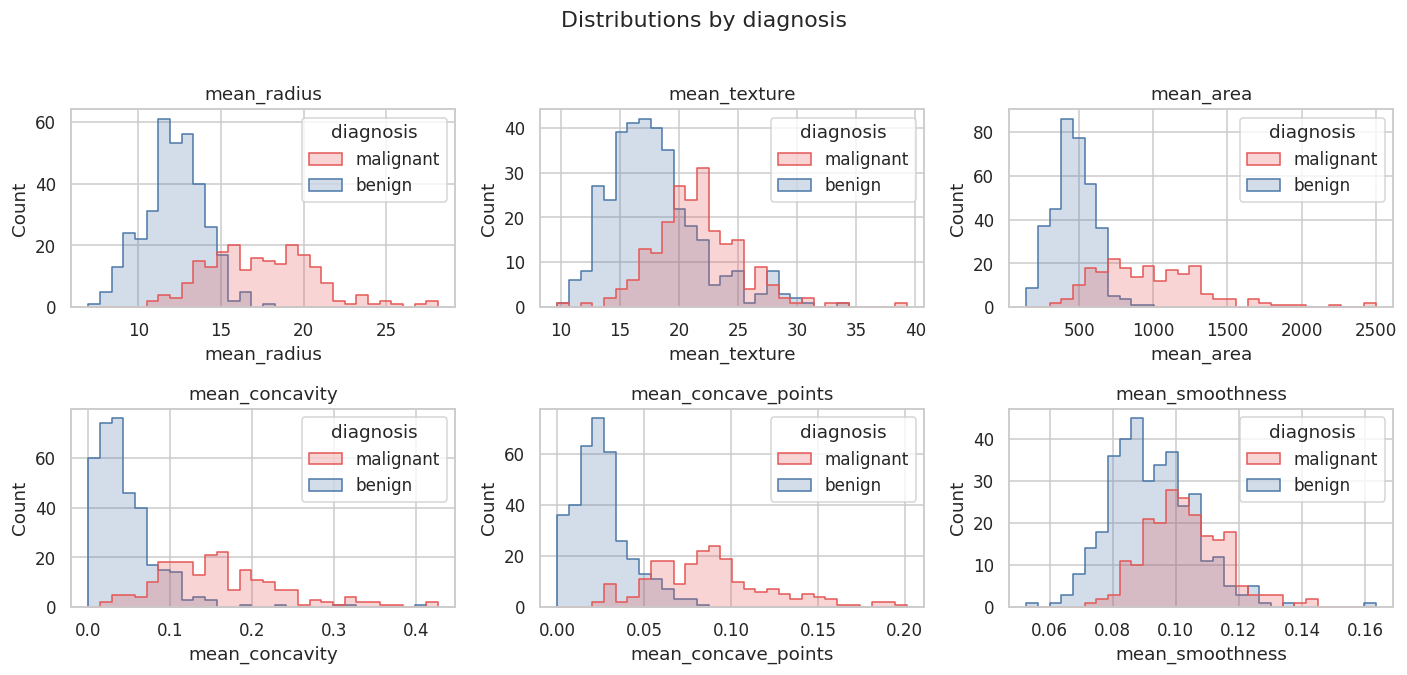

In [6]:
show = ["mean_radius", "mean_texture", "mean_area", "mean_concavity", "mean_concave_points", "mean_smoothness"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, f in zip(axes.ravel(), show):
    sns.histplot(data=eda, x=f, hue="diagnosis", palette=PALETTE, bins=30, element="step", ax=ax)
    ax.set_title(f)
plt.suptitle("Distributions by diagnosis", y=1.02)
plt.tight_layout()

Median by class:
diagnosis             benign  malignant  ratio_malignant_to_benign
mean_radius           12.200     17.325                      1.420
mean_texture          17.390     21.460                      1.234
mean_area            458.400    932.000                      2.033
mean_concavity         0.037      0.151                      4.081
mean_concave_points    0.023      0.086                      3.681
mean_smoothness        0.091      0.102                      1.126


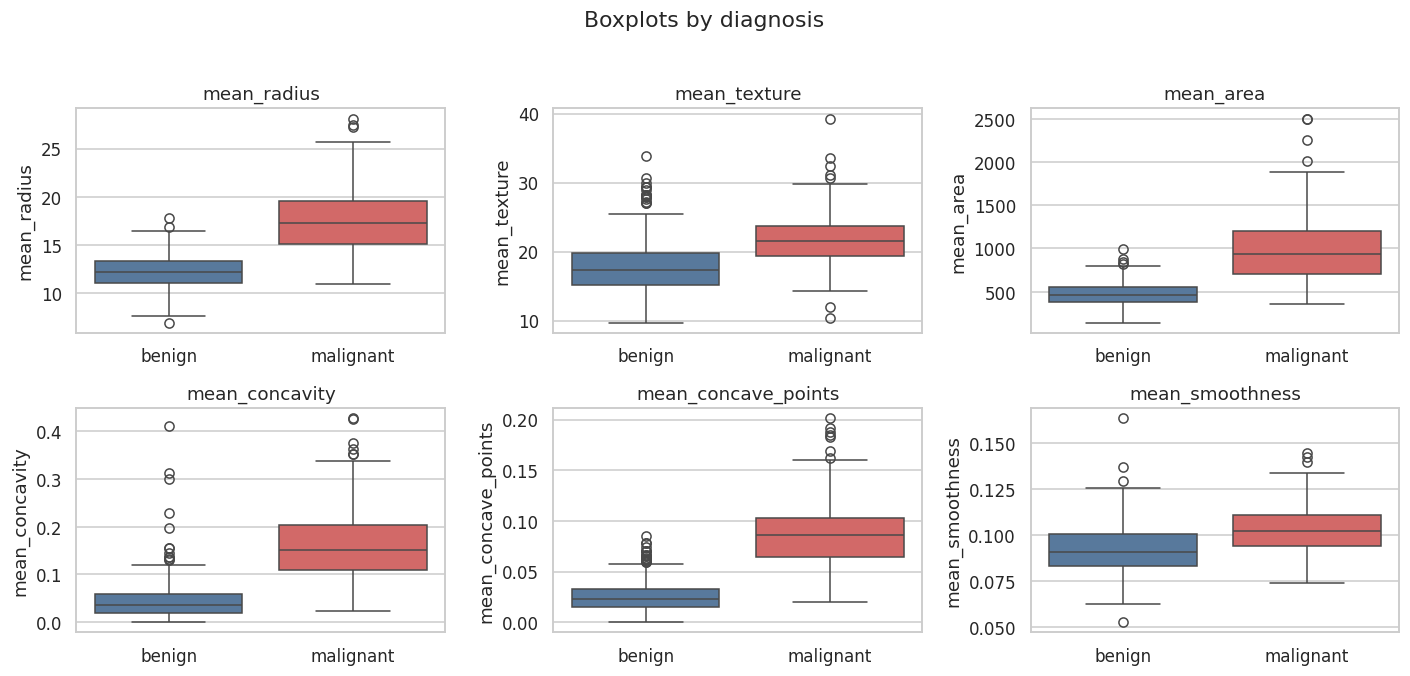

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, f in zip(axes.ravel(), show):
    sns.boxplot(data=eda, x="diagnosis", y=f, order=["benign", "malignant"], hue="diagnosis",
                palette=PALETTE, legend=False, ax=ax)
    ax.set_title(f)
    ax.set_xlabel("")
plt.suptitle("Boxplots by diagnosis", y=1.02)
plt.tight_layout()
plt.savefig("figs/eda_boxplots.png", dpi=130, bbox_inches="tight")

med = eda.groupby("diagnosis")[show].median().T
med["ratio_malignant_to_benign"] = med["malignant"] / med["benign"]
print("Median by class:")
print(med.round(3).to_string())

Top 10 features by |correlation| with malignant:
worst_concave_points    0.794
worst_perimeter         0.783
mean_concave_points     0.777
worst_radius            0.776
mean_perimeter          0.743
worst_area              0.734
mean_radius             0.730
mean_area               0.709
mean_concavity          0.696
worst_concavity         0.660

Feature pairs with |r| > 0.9: 21 of 435


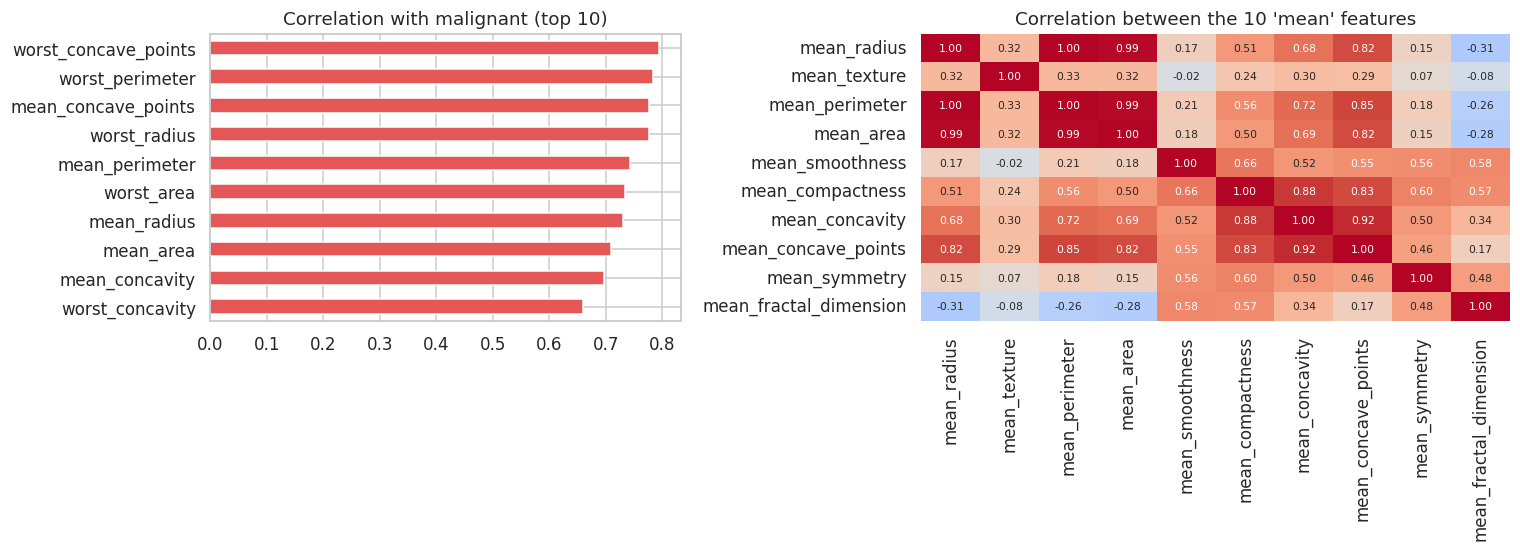

In [8]:
corr = df.corr(numeric_only=True)
target_corr = corr["malignant"].drop("malignant").sort_values(key=abs, ascending=False)
print("Top 10 features by |correlation| with malignant:")
print(target_corr.head(10).round(3).to_string())

fc = corr.drop(index="malignant", columns="malignant")
upper = fc.where(np.triu(np.ones(fc.shape, dtype=bool), k=1))
n_pairs_high = int((upper.abs() > 0.9).sum().sum())
print("\nFeature pairs with |r| > 0.9:", n_pairs_high, "of", int(fc.shape[0] * (fc.shape[0] - 1) / 2))

mean_cols = [c for c in df.columns if c.startswith("mean_")]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1, 1.25]})
target_corr.head(10).sort_values().plot.barh(ax=axes[0], color="#E45756")
axes[0].set_title("Correlation with malignant (top 10)")
sns.heatmap(df[mean_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, ax=axes[1], cbar=False)
axes[1].set_title("Correlation between the 10 'mean' features")
plt.tight_layout()

**Trends identified**
- **Class balance:** 357 benign vs 212 malignant (37.3% malignant). Mildly imbalanced, so we use a stratified split and report recall and precision, not accuracy alone. A model that always says "benign" would already score 62.7% accuracy.
- **Malignant masses are larger and more irregular:** the median mean_area is 932 vs 458 (about 2.0x), median mean_concavity is about 4.1x higher and mean_concave_points about 3.7x higher. Texture (1.23x) and smoothness (1.13x) differ much less.
- **Strongest single correlates of malignancy:** worst_concave_points (r = 0.79), worst_perimeter (0.78), mean_concave_points (0.78).
- **Heavy redundancy:** 21 of 435 feature pairs have |r| > 0.9 (radius, perimeter and area are near-duplicates). This is fine for prediction but means individual feature importances will be shared out and should be read cautiously.

## 3. Feature engineering
**Plan**
- **Split first** (80/20, stratified), so nothing about the test set leaks into cleaning, encoding or scaling.
- **Missing values:** median imputation. **Outliers:** cap at the 1st/99th training percentile. **Scaling:** standardise to mean 0, std 1.
- **Categorical encoding:** the raw data has no categorical column, so we **derive** one, `size_group` (small / medium / large terciles of `mean_radius`), and one-hot encode it. Honest note: it is redundant with `mean_radius`, so it adds little predictive power. It is here to demonstrate encoding and is reused in the Part B subgroup analysis.
- Everything is wrapped in one scikit-learn `Pipeline`, so cross-validation refits every step on each training fold (no leakage), and the same object can be used unchanged behind an API.

In [9]:
X = df.drop(columns="malignant")
y = df["malignant"]
num_cols = list(X.columns)

# Split BEFORE any fitting step, so test data never influences cleaning, encoding or scaling.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Malignant share  train: %.3f   test: %.3f" % (y_train.mean(), y_test.mean()))


class SizeGroup(BaseEstimator, TransformerMixin):
    """Derives a categorical 'size_group' (small / medium / large) from mean_radius terciles."""
    def fit(self, X, y=None):
        self.edges_ = np.nanquantile(X["mean_radius"], [1 / 3, 2 / 3])
        return self

    def transform(self, X):
        X = X.copy()
        r = X["mean_radius"]
        g = np.where(r <= self.edges_[0], "small", np.where(r <= self.edges_[1], "medium", "large")).astype(object)
        g[r.isna().to_numpy()] = "unknown"
        X["size_group"] = g
        return X


class Winsorizer(BaseEstimator, TransformerMixin):
    """Caps each feature at the lower/upper percentile learned on the training data."""
    def __init__(self, lower=1, upper=99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lo_, self.hi_ = np.nanpercentile(X, [self.lower, self.upper], axis=0)
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lo_, self.hi_)


def make_preprocessor(scale=True, clip=True):
    steps = [("impute", SimpleImputer(strategy="median"))]      # missing values -> median
    if clip:
        steps.append(("clip", Winsorizer()))                     # outliers -> capped at 1st/99th percentile
    if scale:
        steps.append(("scale", StandardScaler()))                # mean 0, std 1
    return Pipeline([
        ("derive", SizeGroup()),                                 # creates the categorical column
        ("encode", ColumnTransformer([
            ("num", Pipeline(steps), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), ["size_group"]),
        ])),
    ])


def make_model(clf, **kwargs):
    return Pipeline([("prep", make_preprocessor(**kwargs)), ("clf", clf)])


# Demonstrate what the preprocessing does on the training data
demo = make_preprocessor()
Xt = demo.fit_transform(X_train)
ohe = demo.named_steps["encode"].named_transformers_["cat"]
print("\nTransformed matrix shape:", Xt.shape, "(30 scaled numeric + one-hot size_group columns)")
print("One-hot columns:", list(ohe.get_feature_names_out(["size_group"])))
print("Numeric columns after scaling -> mean %.3f, std %.3f" % (Xt[:, :30].mean(), Xt[:, :30].std(axis=0).mean()))
sg_train = demo.named_steps["derive"].transform(X_train)["size_group"]
print("\nsize_group counts in training data:")
print(sg_train.value_counts().to_string())

Train: (455, 30)  Test: (114, 30)
Malignant share  train: 0.374   test: 0.368

Transformed matrix shape: (455, 33) (30 scaled numeric + one-hot size_group columns)
One-hot columns: ['size_group_large', 'size_group_medium', 'size_group_small']
Numeric columns after scaling -> mean -0.000, std 1.000

size_group counts in training data:
size_group
small     153
large     151
medium    151


## 4. Model development
We compare a majority-class baseline against three models, using 5-fold stratified cross-validation on the training set only. Selection metric: **F1 on the malignant class** (it balances missed cancers against false alarms). The test set is touched once, at the end.

First, a quick ablation to check that the preprocessing choices actually help:

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

variants = {
    "No scaling, no outlier capping": dict(scale=False, clip=False),
    "Scaling only": dict(scale=True, clip=False),
    "Scaling + outlier capping": dict(scale=True, clip=True),
}
rows = []
for name, kw in variants.items():
    res = cross_validate(make_model(LogisticRegression(max_iter=10000), **kw), X_train, y_train,
                         cv=cv, scoring=["accuracy", "recall", "f1"])
    rows.append({"preprocessing": name, "accuracy": res["test_accuracy"].mean(),
                 "recall": res["test_recall"].mean(), "f1": res["test_f1"].mean()})
ablation = pd.DataFrame(rows).set_index("preprocessing")
print("Logistic Regression, 5-fold CV on the training set:")
print(ablation.round(4).to_string())

Logistic Regression, 5-fold CV on the training set:
                                accuracy  recall      f1
preprocessing                                           
No scaling, no outlier capping    0.9538  0.9176  0.9365
Scaling only                      0.9780  0.9588  0.9701
Scaling + outlier capping         0.9824  0.9588  0.9758


**What worked.** Scaling is the clear win: accuracy rises from 0.954 to 0.978 and recall from 0.918 to 0.959. This happens because features live on very different scales (mean_area is in the hundreds, mean_smoothness around 0.1), which slows and distorts the regularised logistic regression fit. Outlier capping adds a further +0.004 accuracy, which is a very small effect (about one patient per fold), so treat it as a cheap safeguard rather than a proven improvement.

In [11]:
candidates = {
    "Baseline (majority class)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

rows = []
for name, clf in candidates.items():
    res = cross_validate(make_model(clf), X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"model": name, **{m: res[f"test_{m}"].mean() for m in scoring},
                 "f1_std": res["test_f1"].std()})
cv_table = pd.DataFrame(rows).set_index("model")
print("5-fold stratified CV on the training set (mean of folds):")
print(cv_table.round(4).to_string())

best_family = cv_table.drop(index="Baseline (majority class)")["f1"].idxmax()
print("\nBest family by CV F1:", best_family)

5-fold stratified CV on the training set (mean of folds):
                           accuracy  precision  recall      f1  roc_auc  f1_std
model                                                                          
Baseline (majority class)    0.6264     0.0000  0.0000  0.0000   0.5000  0.0000
Logistic Regression          0.9824     0.9941  0.9588  0.9758   0.9951  0.0156
Random Forest                0.9648     0.9695  0.9353  0.9519   0.9881  0.0308
Gradient Boosting            0.9670     0.9707  0.9412  0.9551   0.9908  0.0168

Best family by CV F1: Logistic Regression


**Result.** All three real models beat the baseline by a wide margin. **Logistic Regression** has the best CV F1 (0.976, vs 0.952 for Random Forest and 0.955 for Gradient Boosting). The fold-to-fold standard deviation is 0.016 to 0.031, so the honest reading is "all three are strong; logistic regression is at least as good and is the simplest and most interpretable", not "it is decisively better". Next we tune the chosen model.

In [12]:
grids = {
    "Logistic Regression": {"clf__C": [0.01, 0.1, 1, 10, 100]},
    "Random Forest": {"clf__max_depth": [3, 5, None], "clf__min_samples_leaf": [1, 3, 5]},
    "Gradient Boosting": {"clf__learning_rate": [0.05, 0.1], "clf__max_depth": [2, 3]},
}
gs = GridSearchCV(make_model(candidates[best_family]), grids[best_family], cv=cv, scoring="f1")
gs.fit(X_train, y_train)
final_model = gs.best_estimator_

print("Tuned model:", best_family)
print("Best parameters:", gs.best_params_)
print("CV F1 of tuned model: %.4f (untuned: %.4f)" % (gs.best_score_, cv_table.loc[best_family, "f1"]))

Tuned model: Logistic Regression
Best parameters: {'clf__C': 1}
CV F1 of tuned model: 0.9758 (untuned: 0.9758)


**Result.** Tuning gave **no improvement** (best C = 1, the default). That is a useful finding in itself: the default regularisation was already appropriate, so extra tuning would only add the risk of over-fitting the validation folds.

### Final evaluation on the held-out test set

accuracy   0.9825
precision  1.0000
recall     0.9524
f1         0.9756
roc_auc    0.9957
brier      0.0192
rmse_prob  0.1386

(RMSE is a regression metric. Here it is computed on predicted probabilities as sqrt(Brier score).)

Confusion matrix  TN=72  FP=0  FN=2  TP=40

              precision    recall  f1-score   support

      benign      0.973     1.000     0.986        72
   malignant      1.000     0.952     0.976        42

    accuracy                          0.982       114
   macro avg      0.986     0.976     0.981       114
weighted avg      0.983     0.982     0.982       114



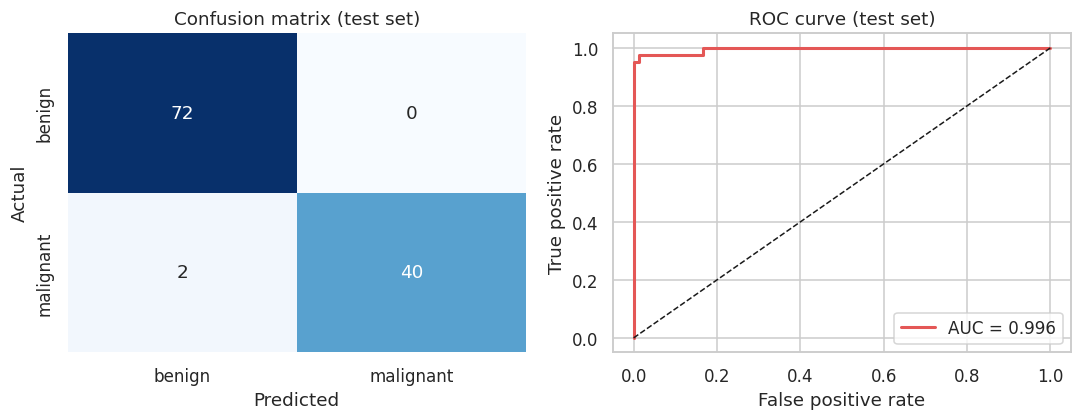

In [13]:
# Wilson score interval: a 95% confidence interval for a proportion, sensible for small samples
def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return centre - half, centre + half


THRESH = 0.5
proba = final_model.predict_proba(X_test)[:, 1]
pred = (proba >= THRESH).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1": f1_score(y_test, pred),
    "roc_auc": roc_auc_score(y_test, proba),
    "brier": brier_score_loss(y_test, proba),
}
metrics["rmse_prob"] = float(np.sqrt(metrics["brier"]))
for k, v in metrics.items():
    print("%-10s %.4f" % (k, v))
print("\n(RMSE is a regression metric. Here it is computed on predicted probabilities as sqrt(Brier score).)")

cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()
print("\nConfusion matrix  TN=%d  FP=%d  FN=%d  TP=%d" % (tn, fp, fn, tp))
print()
print(classification_report(y_test, pred, target_names=["benign", "malignant"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["benign", "malignant"], yticklabels=["benign", "malignant"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual"); axes[0].set_title("Confusion matrix (test set)")
fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr, color="#E45756", lw=2, label="AUC = %.3f" % metrics["roc_auc"])
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve (test set)"); axes[1].legend(loc="lower right")
plt.tight_layout()
plt.savefig("figs/confusion_roc.png", dpi=130, bbox_inches="tight")

**Result.** On 114 unseen samples the model reaches **accuracy 0.982, precision 1.000, recall 0.952, F1 0.976 and ROC-AUC 0.996**. The confusion matrix shows 72 true negatives, 0 false positives, **2 false negatives** and 40 true positives. These test numbers are consistent with the cross-validation numbers (CV accuracy about 0.982), which is what we want to see.

Keep the sample size in mind: with 114 test cases, each error moves accuracy by about 0.9%. The 95% confidence interval for accuracy is roughly 0.94 to 1.00, and for recall 0.84 to 0.99. The task asked for RMSE as one possible metric; that is for regression, so for this classifier we report accuracy, precision, recall, F1, AUC and the confusion matrix, plus an RMSE on predicted probabilities (0.139) for completeness.

Top 10 features by permutation importance (drop in test ROC-AUC when shuffled):
worst_texture           0.0063
worst_symmetry          0.0032
worst_concavity         0.0026
texture_error           0.0022
worst_concave_points    0.0022
mean_concave_points     0.0017
worst_smoothness        0.0014
worst_radius            0.0013
worst_area              0.0008
compactness_error       0.0008

Misclassified test cases:
    actual  predicted  p_malignant
99       1          0        0.409
73       1          0        0.042


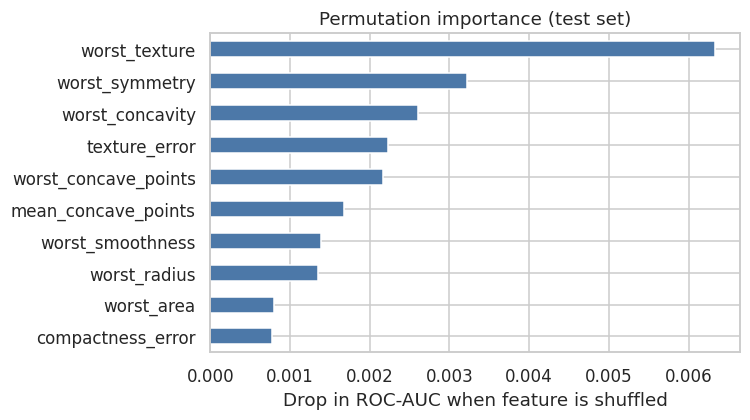

In [14]:
pi = permutation_importance(final_model, X_test, y_test, n_repeats=15, random_state=RANDOM_STATE, scoring="roc_auc")
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values(ascending=False)
print("Top 10 features by permutation importance (drop in test ROC-AUC when shuffled):")
print(imp.head(10).round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
imp.head(10).sort_values().plot.barh(ax=ax, color="#4C78A8")
ax.set_xlabel("Drop in ROC-AUC when feature is shuffled")
ax.set_title("Permutation importance (test set)")
plt.tight_layout()

wrong = pd.DataFrame({"actual": y_test, "predicted": pred, "p_malignant": proba.round(3)}, index=X_test.index)
wrong = wrong[wrong["actual"] != wrong["predicted"]]
print("\nMisclassified test cases:")
print(wrong.to_string() if len(wrong) else "none")

**Interpretation.** Permutation importances are small and spread out (worst_texture, worst_symmetry and worst_concavity lead). That does not mean the model is weak; it is the redundancy we saw in the EDA: when several features carry the same signal, shuffling any one of them barely hurts. So this chart shows what the model relies on *uniquely*, which differs from the univariate correlation ranking (size and concave-point features). Do not read it as a causal or clinical statement.

**Errors.** Both mistakes were missed cancers: case 99 (true malignant, model probability 0.41), case 73 (true malignant, model probability 0.04). The first is a near miss that a slightly lower decision threshold would catch (see the threshold test in Part B). The second is a confident miss that no threshold would fix.

## 5. Report of findings

**What worked and why**
- **Standardising the features** was the single biggest preprocessing gain (see the ablation), because the features sit on very different numeric scales.
- **A simple model won.** Regularised logistic regression matched or beat Random Forest and Gradient Boosting (CV F1 0.976 vs 0.952 and 0.955). With only 455 training rows and classes that are nearly linearly separable on the strong size and shape features, flexible models have little extra to learn.
- **The pipeline design** (split first, then impute, cap, scale and encode inside cross-validation) kept the evaluation honest: test performance (0.982 accuracy) agrees with cross-validation.

**Visual results and interpretation**
- Boxplots and histograms show malignant masses are larger and more concave, with clear separation on the size and concavity features, which explains why even a linear model does well.
- The confusion matrix and ROC curve show strong ranking ability (AUC 0.996) and **zero false alarms but 2 missed cancers**.

**Limitations**
- Small test set (114 rows), so metrics are imprecise.
- One dataset from one source, one train/test split; no external validation.
- The features were extracted from images by a specific 1990s measurement process, so performance may not carry over to other labs or equipment.
- In a screening setting a missed cancer is far more costly than a false alarm, so the default 0.5 threshold is probably not the right operating point (explored in Part B).

**Next steps:** repeated cross-validation or a bigger hold-out set, external data, calibration checks, and choosing the threshold from a cost-based analysis agreed with domain experts.

---
# Part B: Model Testing

This part critically evaluates the Part A model. The summary report (2-3 page PDF) is a separate file; the code that produced every number in it is below.

## B1. Testing strategy: validation plan
- **Hold-out test set:** 20% of the data (stratified so the malignant share is preserved), locked away until the final evaluation. It was used once for the reported test results.
- **Cross-validation:** 5-fold stratified CV on the training set for model comparison, preprocessing ablation and hyper-parameter tuning. Every preprocessing step is inside the pipeline, so it is refit within each fold (no leakage).
- **Fixed random seed** (42) for reproducibility.
- **Why not only a single split?** With 569 rows a single split is noisy. CV gives a mean and a spread for the training-side decisions, and the hold-out set gives an unbiased final check.

In [15]:
print("Hold-out split: %d train / %d test, stratified, random_state=%d" % (len(X_train), len(X_test), RANDOM_STATE))
print("Malignant share  full: %.3f  train: %.3f  test: %.3f" % (y.mean(), y_train.mean(), y_test.mean()))
print("\nCross-validation folds (5-fold stratified, inside the training set):")
for i, (tr, va) in enumerate(cv.split(X_train, y_train), 1):
    print("  fold %d: train=%d  validation=%d  malignant share in validation=%.3f" % (i, len(tr), len(va), y_train.iloc[va].mean()))

Hold-out split: 455 train / 114 test, stratified, random_state=42
Malignant share  full: 0.373  train: 0.374  test: 0.368

Cross-validation folds (5-fold stratified, inside the training set):
  fold 1: train=364  validation=91  malignant share in validation=0.374
  fold 2: train=364  validation=91  malignant share in validation=0.374
  fold 3: train=364  validation=91  malignant share in validation=0.374
  fold 4: train=364  validation=91  malignant share in validation=0.374
  fold 5: train=364  validation=91  malignant share in validation=0.374


## B2. Metrics chosen and why
| Metric | Why it is used here |
|---|---|
| **Recall (sensitivity) for malignant** | A false negative is a missed cancer. This is the metric we most want high. |
| **Precision for malignant** | Controls false alarms (unnecessary follow-up procedures and anxiety). |
| **F1 (malignant)** | One number balancing precision and recall, used to pick the model. |
| **Accuracy** | Easy to read, but misleading alone because an "always benign" model already gets about 63%. Reported next to the baseline. |
| **ROC-AUC** | Threshold-free measure of how well malignant cases are ranked above benign ones. |
| **Confusion matrix** | Shows the actual counts of each error type. |
| **Brier score / probability RMSE** | Checks that predicted probabilities are sensible, not just the labels. |

## B3. QA functional test: overfitting and underfitting
**Method.** Compare train, cross-validation and test accuracy for the final model against two deliberate probes: a depth-1 decision stump (expected to underfit) and an unpruned decision tree (expected to overfit), plus the majority-class baseline. A learning curve shows whether more data would help.

                                           train_acc  cv_acc  test_acc  train_minus_cv
model                                                                                 
Majority-class baseline                       0.6264  0.6264    0.6316          0.0000
Decision stump (depth 1) - underfit probe     0.9297  0.9011    0.8772          0.0286
Unpruned decision tree - overfit probe        1.0000  0.9297    0.9211          0.0703
FINAL: Logistic Regression (tuned)            0.9846  0.9824    0.9825          0.0022

Gap between training and CV accuracy at full size: 0.0055


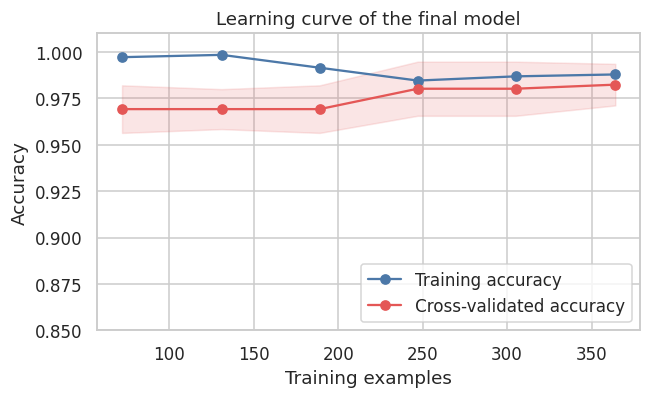

In [16]:
def acc_report(name, clf):
    m = make_model(clf)
    cv_acc = cross_val_score(m, X_train, y_train, cv=cv, scoring="accuracy").mean()
    m.fit(X_train, y_train)
    return {"model": name, "train_acc": m.score(X_train, y_train), "cv_acc": cv_acc, "test_acc": m.score(X_test, y_test)}

fit_rows = [
    acc_report("Majority-class baseline", DummyClassifier(strategy="most_frequent")),
    acc_report("Decision stump (depth 1) - underfit probe", DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)),
    acc_report("Unpruned decision tree - overfit probe", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    acc_report("FINAL: " + best_family + " (tuned)", clone(final_model.named_steps["clf"])),
]
fit_table = pd.DataFrame(fit_rows).set_index("model")
fit_table["train_minus_cv"] = fit_table["train_acc"] - fit_table["cv_acc"]
print(fit_table.round(4).to_string())

sizes, tr_scores, va_scores = learning_curve(final_model, X_train, y_train, cv=cv, scoring="accuracy",
                                             train_sizes=np.linspace(0.2, 1.0, 6), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(sizes, tr_scores.mean(axis=1), "o-", color="#4C78A8", label="Training accuracy")
ax.plot(sizes, va_scores.mean(axis=1), "o-", color="#E45756", label="Cross-validated accuracy")
ax.fill_between(sizes, va_scores.mean(axis=1) - va_scores.std(axis=1), va_scores.mean(axis=1) + va_scores.std(axis=1),
                color="#E45756", alpha=0.15)
ax.set_xlabel("Training examples"); ax.set_ylabel("Accuracy"); ax.set_ylim(0.85, 1.01)
ax.set_title("Learning curve of the final model"); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figs/learning_curve.png", dpi=130, bbox_inches="tight")
print("\nGap between training and CV accuracy at full size: %.4f" % (tr_scores.mean(axis=1)[-1] - va_scores.mean(axis=1)[-1]))

**Findings**
- **No sign of overfitting in the final model:** train 0.985, CV 0.982, test 0.982. The train-minus-CV gap is 0.002. By contrast, the unpruned tree shows the classic overfit pattern (train 1.000, CV 0.930, gap 0.070).
- **No sign of underfitting:** the final model scores far above the baseline (0.632) and above the deliberately underfit stump (0.877 test accuracy).
- **Learning curve:** the training and validation curves converge as data grows (the gap narrows from roughly 0.03 at 70 examples to about 0.005 at full size), which is the pattern of a model that is not over-fitting. Validation accuracy is still creeping up slightly at the right-hand edge, so more data might help a little, but there is no large gap signalling high variance.

## B4. QA functional test: robustness to noisy, missing and wrongly-scaled inputs
**Method.** Perturb the test inputs and measure how performance changes: (1) Gaussian noise, (2) randomly missing values, (3) a unit/scale bug that multiplies values by 10.

In [17]:
rng = np.random.default_rng(0)
stds = X_train.std().to_numpy()

print("1) Gaussian noise added to every feature (noise = k x feature std), 20 repeats each")
noise_rows = []
for k in [0, 0.05, 0.10, 0.25, 0.50]:
    accs, recs = [], []
    for _ in range(20):
        Xn = X_test + rng.normal(0, 1, X_test.shape) * stds * k
        p = final_model.predict(Xn)
        accs.append(accuracy_score(y_test, p)); recs.append(recall_score(y_test, p))
    noise_rows.append({"noise_k": k, "accuracy": np.mean(accs), "recall": np.mean(recs)})
noise_table = pd.DataFrame(noise_rows).set_index("noise_k")
print(noise_table.round(4).to_string())

print("\n2) Randomly missing values (handled by median imputation inside the pipeline)")
miss_rows = []
for frac in [0.0, 0.05, 0.10, 0.20]:
    accs = []
    for _ in range(20):
        mask = pd.DataFrame(rng.random(X_test.shape) < frac, index=X_test.index, columns=X_test.columns)
        p = final_model.predict(X_test.mask(mask))
        accs.append(accuracy_score(y_test, p))
    miss_rows.append({"missing_fraction": frac, "accuracy": np.mean(accs)})
miss_table = pd.DataFrame(miss_rows).set_index("missing_fraction")
print(miss_table.round(4).to_string())

print("\n3) Unit/scale error: a data-entry bug that multiplies feature values by 10")
unit_rows = []
for label, Xu in [("no error", X_test),
                  ("mean_radius x10 only", X_test.assign(mean_radius=X_test["mean_radius"] * 10)),
                  ("all features x10", X_test * 10)]:
    p = final_model.predict(Xu)
    unit_rows.append({"scenario": label, "accuracy": accuracy_score(y_test, p), "recall": recall_score(y_test, p),
                      "share_predicted_malignant": p.mean()})
unit_table = pd.DataFrame(unit_rows).set_index("scenario")
print(unit_table.round(4).to_string())

1) Gaussian noise added to every feature (noise = k x feature std), 20 repeats each
         accuracy  recall
noise_k                  
0.00       0.9825  0.9524
0.05       0.9768  0.9417
0.10       0.9781  0.9464
0.25       0.9706  0.9393
0.50       0.9539  0.9310

2) Randomly missing values (handled by median imputation inside the pipeline)
                  accuracy
missing_fraction          
0.00                0.9825
0.05                0.9711
0.10                0.9654
0.20                0.9452

3) Unit/scale error: a data-entry bug that multiplies feature values by 10
                      accuracy  recall  share_predicted_malignant
scenario                                                         
no error                0.9825  0.9524                     0.3509
mean_radius x10 only    0.9649  0.9762                     0.3860
all features x10        0.3684  1.0000                     1.0000


**Findings**
- **Noise:** graceful degradation. Accuracy goes from 0.982 to 0.954 even when noise is half a standard deviation of each feature.
- **Missing values:** the imputation step works (no crashes). Accuracy falls to 0.945 with 20% of values missing, which is acceptable, but median imputation is a blunt tool and a production system should still flag how many fields were missing.
- **Unit/scale error: a silent failure.** If a single feature is off by 10x, accuracy barely changes (0.965). If **all** features are off by 10x, the model predicts "malignant" for everything: accuracy 0.368, and nothing raises an error. This is exactly why the API test cases below include range checks.

## B5. QA functional test: fairness across subgroups
**Method.** Break test performance down by subgroup. This dataset contains **no demographic attributes** (no age, race, sex or similar), so a demographic fairness audit is impossible with this data, which is itself a finding. As a proxy we compare technical subgroups: tumour-size terciles and low/high texture.

Subgroups by tumour size (mean_radius terciles from training data):
         n  malignant_share  accuracy acc_95%_CI  recall  precision  FPR    FNR  FN  FP
group                                                                                  
large   34            0.882     1.000  0.90-1.00   1.000        1.0  0.0  0.000   0   0
medium  42            0.286     0.952  0.84-0.99   0.833        1.0  0.0  0.167   2   0
small   38            0.000     1.000  0.91-1.00     NaN        NaN  0.0    NaN   0   0

Subgroups by mean_texture (split at the training median):
               n  malignant_share  accuracy acc_95%_CI  recall  precision  FPR    FNR  FN  FP
group                                                                                        
high texture  51            0.647     0.980  0.90-1.00   0.970        1.0  0.0  0.030   1   0
low texture   63            0.143     0.984  0.92-1.00   0.889        1.0  0.0  0.111   1   0

[size] accuracy gap (max-min): 0.048 | recall gap: 0.167

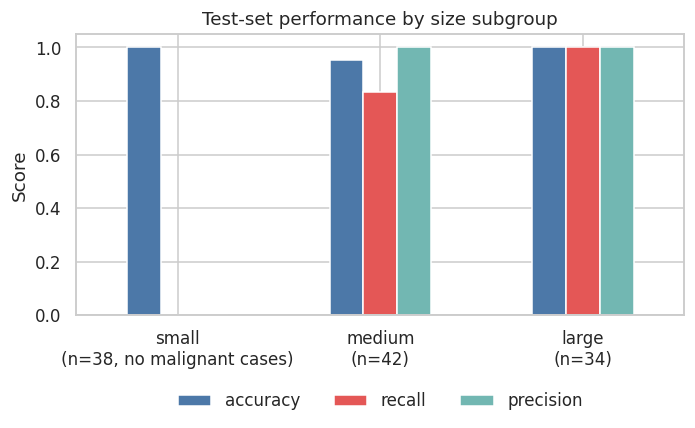

In [18]:
def safe_div(a, b):
    return a / b if b else np.nan


def subgroup_table(labels):
    rows = []
    yt = y_test.to_numpy()
    for g in sorted(set(labels)):
        m = labels == g
        t, p = yt[m], pred[m]
        tn_, fp_, fn_, tp_ = ((t == 0) & (p == 0)).sum(), ((t == 0) & (p == 1)).sum(), ((t == 1) & (p == 0)).sum(), ((t == 1) & (p == 1)).sum()
        lo, hi = wilson(tn_ + tp_, m.sum())
        rows.append({"group": g, "n": int(m.sum()), "malignant_share": t.mean(),
                     "accuracy": (tn_ + tp_) / m.sum(), "acc_95%_CI": "%.2f-%.2f" % (lo, hi),
                     "recall": safe_div(tp_, tp_ + fn_), "precision": safe_div(tp_, tp_ + fp_),
                     "FPR": safe_div(fp_, fp_ + tn_), "FNR": safe_div(fn_, fn_ + tp_),
                     "FN": int(fn_), "FP": int(fp_)})
    return pd.DataFrame(rows).set_index("group")


size_labels = final_model.named_steps["prep"].named_steps["derive"].transform(X_test)["size_group"].to_numpy()
tex_labels = np.where(X_test["mean_texture"] <= X_train["mean_texture"].median(), "low texture", "high texture")

fair_size = subgroup_table(size_labels)
fair_tex = subgroup_table(tex_labels)
print("Subgroups by tumour size (mean_radius terciles from training data):")
print(fair_size.round(3).to_string())
print("\nSubgroups by mean_texture (split at the training median):")
print(fair_tex.round(3).to_string())

for name, t in [("size", fair_size), ("texture", fair_tex)]:
    print("\n[%s] accuracy gap (max-min): %.3f | recall gap: %s | FPR gap: %s" % (
        name, t["accuracy"].max() - t["accuracy"].min(),
        "%.3f" % (t["recall"].max() - t["recall"].min()) if t["recall"].notna().sum() > 1 else "n/a",
        "%.3f" % (t["FPR"].max() - t["FPR"].min()) if t["FPR"].notna().sum() > 1 else "n/a"))

order = ["small", "medium", "large"]
plot_df = fair_size.loc[[g for g in order if g in fair_size.index], ["accuracy", "recall", "precision"]]
ax = plot_df.plot.bar(figsize=(6.5, 4.2), color=["#4C78A8", "#E45756", "#72B7B2"], rot=0)
ax.set_ylim(0, 1.05); ax.set_ylabel("Score"); ax.set_xlabel("")
ax.set_title("Test-set performance by size subgroup")
ax.set_xticklabels(["%s\n(n=%d%s)" % (g, fair_size.loc[g, "n"],
                                     ", no malignant cases" if fair_size.loc[g, "malignant_share"] == 0 else "")
                    for g in plot_df.index])
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig("figs/subgroup_performance.png", dpi=130, bbox_inches="tight")

**Findings**
- **Size groups:** the small group has no malignant cases at all in the test set (n = 38), so recall is undefined there. Recall is 1.000 for large and 0.833 for medium masses. Both missed cancers sit in the **medium** group. A plausible but untested explanation is that medium-sized malignant masses overlap more with benign ones.
- **Texture groups:** recall is 0.970 (high texture) vs 0.889 (low texture); false-positive rate is 0 in both.
- **How much weight to give this:** each recall gap is driven by **one or two patients** out of 9 to 12 malignant cases per group, and the accuracy confidence intervals are wide. The data **cannot tell us whether a real disparity exists**; it only shows where to look. A larger test set (or repeated CV predictions) is needed before drawing conclusions. The directional signal (more misses on medium and low-texture masses) is worth monitoring.

## B6. Decision-threshold test
The default threshold (0.5) is not necessarily the right trade-off when a missed cancer is worse than a false alarm. The table shows how errors change with the threshold on the test set.

In [19]:
rows = []
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    p = (proba >= t).astype(int)
    rows.append({"threshold": t, "precision": precision_score(y_test, p), "recall": recall_score(y_test, p),
                 "false_negatives": int(((y_test == 1) & (p == 0)).sum()),
                 "false_positives": int(((y_test == 0) & (p == 1)).sum())})
thr_table = pd.DataFrame(rows).set_index("threshold")
print(thr_table.round(3).to_string())

           precision  recall  false_negatives  false_positives
threshold                                                     
0.1            0.891   0.976                1                5
0.2            0.932   0.976                1                3
0.3            0.953   0.976                1                2
0.4            0.976   0.976                1                1
0.5            1.000   0.952                2                0
0.6            1.000   0.929                3                0
0.7            1.000   0.905                4                0
0.8            1.000   0.857                6                0
0.9            1.000   0.810                8                0


**Findings.** Lowering the threshold from 0.5 to 0.4 recovers the near-miss case (false negatives 2 to 1) at the cost of 1 false alarm. The remaining miss (probability about 0.04) is not recoverable without flagging many benign cases.

**Caution.** This table is computed on the test set to *illustrate* the trade-off. A real threshold must be chosen on validation data (or cross-validated predictions) with input from clinicians about the relative cost of each error type. Choosing it on the test set would make the test result optimistic.

## B7. API / integration tests
The model is **not deployed** in this project, so the cell below builds a small stand-in for a `POST /predict` endpoint (input validation + the saved pipeline) and runs the test cases that a real deployment would need: expected input, unexpected input, boundary values, consistency and latency.

In [20]:
FEATURES = list(X_train.columns)
train_min, train_max = X_train.min(), X_train.max()


def validate_payload(payload):
    """Returns an error message, or None if the payload is acceptable."""
    if not isinstance(payload, dict):
        return "payload must be a JSON object"
    missing = [f for f in FEATURES if f not in payload]
    if missing:
        return "missing fields: %s%s" % (missing[:3], "..." if len(missing) > 3 else "")
    for f in FEATURES:
        v = payload[f]
        if isinstance(v, bool) or not isinstance(v, numbers.Real):
            return "%s must be a number" % f
        if not np.isfinite(v):
            return "%s must be finite" % f
        if v < 0:
            return "%s must be non-negative" % f
    return None


def predict_endpoint(payload):
    """A stand-in for POST /predict. The model is NOT deployed; this harness lets us test the contract."""
    err = validate_payload(payload)
    if err:
        return {"status": 422, "error": err}
    warnings_ = ["%s outside expected range" % f for f in FEATURES
                 if not (train_min[f] * 0.5 <= payload[f] <= train_max[f] * 2)]
    extras = [k for k in payload if k not in FEATURES]
    if extras:
        warnings_.append("ignored unknown fields: %s" % extras)
    row = pd.DataFrame([{f: payload[f] for f in FEATURES}])
    p = float(final_model.predict_proba(row)[0, 1])
    return {"status": 200, "label": "malignant" if p >= THRESH else "benign",
            "probability_malignant": round(p, 4), "warnings": warnings_}


ok_benign = X_test[(y_test == 0) & (pred == 0)].iloc[0].to_dict()
ok_malig = X_test[(y_test == 1) & (pred == 1)].iloc[0].to_dict()

tests = [
    ("T1  valid benign sample",            ok_benign,                                   lambda r: r["status"] == 200 and r["label"] == "benign",    "200, label=benign"),
    ("T2  valid malignant sample",         ok_malig,                                    lambda r: r["status"] == 200 and r["label"] == "malignant", "200, label=malignant"),
    ("T3  one required field missing",     {k: v for k, v in ok_benign.items() if k != "mean_area"}, lambda r: r["status"] == 422,                  "422 error"),
    ("T4  empty payload",                  {},                                          lambda r: r["status"] == 422,                               "422 error"),
    ("T5  payload is a list, not object",  [1, 2, 3],                                   lambda r: r["status"] == 422,                               "422 error"),
    ("T6  number sent as string",          {**ok_benign, "mean_radius": "12.5"},         lambda r: r["status"] == 422,                               "422 error"),
    ("T7  NaN value",                      {**ok_benign, "mean_radius": float("nan")},   lambda r: r["status"] == 422,                               "422 error"),
    ("T8  negative measurement",           {**ok_benign, "mean_area": -5},               lambda r: r["status"] == 422,                               "422 error"),
    ("T9  extra unknown field",            {**ok_benign, "patient_name": "X"},           lambda r: r["status"] == 200 and r["label"] == "benign" and any("unknown" in w for w in r["warnings"]), "200, same label, warning"),
    ("T10 every value x100 (implausible)", {k: v * 100 for k, v in ok_benign.items()},   lambda r: r["status"] == 200 and len(r["warnings"]) > 0,    "200 with out-of-range warnings"),
    ("T11 boundary: training minimums",    train_min.to_dict(),                         lambda r: r["status"] == 200 and 0 <= r["probability_malignant"] <= 1, "200, valid probability"),
    ("T12 boundary: training maximums",    train_max.to_dict(),                         lambda r: r["status"] == 200 and 0 <= r["probability_malignant"] <= 1, "200, valid probability"),
]

api_rows = []
for name, payload, check, expected in tests:
    try:
        resp = predict_endpoint(payload)
        actual = ("%d %s" % (resp["status"], resp.get("label", resp.get("error", ""))))[:42]
        passed = bool(check(resp))
    except Exception as e:
        actual, passed = "CRASH: %s" % type(e).__name__, False
    api_rows.append({"test": name, "expected": expected, "actual": actual, "pass": "PASS" if passed else "FAIL"})
api_table = pd.DataFrame(api_rows).set_index("test")
print(api_table.to_string())

# Consistency and determinism: endpoint output must equal direct model output, and repeat calls must match
sample = X_test.iloc[:25]
direct = final_model.predict_proba(sample)[:, 1]
via_api = np.array([predict_endpoint(r.to_dict())["probability_malignant"] for _, r in sample.iterrows()])
consistent = bool(np.allclose(direct, via_api, atol=1e-4))
repeat_same = predict_endpoint(ok_malig) == predict_endpoint(ok_malig)
t0 = time.perf_counter()
for _ in range(50):
    predict_endpoint(ok_benign)
latency_ms = (time.perf_counter() - t0) / 50 * 1000
n_pass = int((api_table["pass"] == "PASS").sum())
print("\nEndpoint matches direct model output on 25 rows:", consistent)
print("Repeat call returns identical response:", repeat_same)
print("Mean latency per single-row call: %.1f ms" % latency_ms)
print("Functional tests passed: %d / %d" % (n_pass, len(api_table)))

                                                          expected                                      actual  pass
test                                                                                                                
T1  valid benign sample                          200, label=benign                                  200 benign  PASS
T2  valid malignant sample                    200, label=malignant                               200 malignant  PASS
T3  one required field missing                           422 error           422 missing fields: ['mean_area']  PASS
T4  empty payload                                        422 error  422 missing fields: ['mean_radius', 'mean_  PASS
T5  payload is a list, not object                        422 error           422 payload must be a JSON object  PASS
T6  number sent as string                                422 error            422 mean_radius must be a number  PASS
T7  NaN value                                            422 err

**Findings.** 12 of 12 functional cases pass. Malformed input (missing field, wrong type, NaN, negative, empty or non-object payload) is rejected with a clear 422-style error instead of crashing or returning a silent wrong answer. Implausible values (x100) and unknown extra fields are accepted but flagged with warnings. The endpoint output matches direct model output (consistent: True), repeat calls return identical results (deterministic: True), and a single-row call takes about 5 ms locally.

**Gaps a real deployment would still need:** authentication and rate limiting, request-size limits for batch calls, model-version and input-schema versioning in the response, logging of inputs and outputs for monitoring drift, and load testing.

## B8. Responsible AI appendix

**Possible sources of bias**
1. **Sampling / representation:** the data come from one institution and one era. We do not know the age, ethnicity or background of the patients, or the imaging equipment, so we cannot say who the model would work worse for.
2. **No protected attributes recorded:** it is impossible to audit performance across demographic groups, so absence of evidence of bias here is not evidence of fairness.
3. **Label bias:** diagnoses reflect pathologists' decisions and the clinical practice of the time.
4. **Measurement bias:** features come from image analysis, which depends on staining, scanner and software; a different lab could shift the feature distributions.
5. **Class imbalance and small groups:** 37% malignant overall, and some subgroups have very few malignant cases, so errors there are poorly measured.
6. **Evaluation bias:** a single small test set and one random split.
7. **Deployment risk (automation bias):** users may trust a 98% accurate model too much, and a unit error would silently produce confident wrong answers (see B4).

**Mitigation strategies**
- Collect and document demographic and equipment metadata; evaluate on multi-site, external data before any use.
- Report subgroup metrics with confidence intervals; set a minimum acceptable recall for every subgroup; use repeated CV or larger test sets to get stable estimates.
- Choose the threshold from a cost-based analysis with domain experts; consider re-weighting or oversampling if subgroup recall is genuinely lower.
- Add strict input validation and out-of-range warnings, drift monitoring and alerting in production (see B7).
- Keep a human in the loop: the model supports a clinician, it does not replace one. Publish a model card with intended use, limitations and known failure modes.
- Re-test regularly and after any change in equipment or population.

---
## Summary of results
| Item | Result |
|---|---|
| Final model | Logistic Regression (C = 1) in a full preprocessing pipeline |
| Test accuracy / precision / recall / F1 / AUC | 0.982 / 1.000 / 0.952 / 0.976 / 0.996 |
| Errors on 114 test cases | 0 false positives, 2 false negatives |
| Overfitting check | Train-minus-CV accuracy gap 0.002 (no overfitting) |
| Biggest robustness risk | Silent failure when all inputs are mis-scaled (accuracy 0.368) |
| Fairness | Cannot audit demographics (not in data); small technical-subgroup gaps rest on 1-2 patients |
| API test cases | 12 / 12 pass |